In [2]:
# Testing the kernel

print("hello world")

hello world


In [3]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Add src to path to import our modules
sys.path.append(os.path.abspath("../src"))

import config
from dataset import HubbleDataProcessor, HubbleDataset
from model import ZeroTrustAutoencoder

print("Environment Ready.")


Environment Ready.


🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_training_data.json...
✅ Filtered down to 100 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.
 Simulating Training to capture Loss Curve...


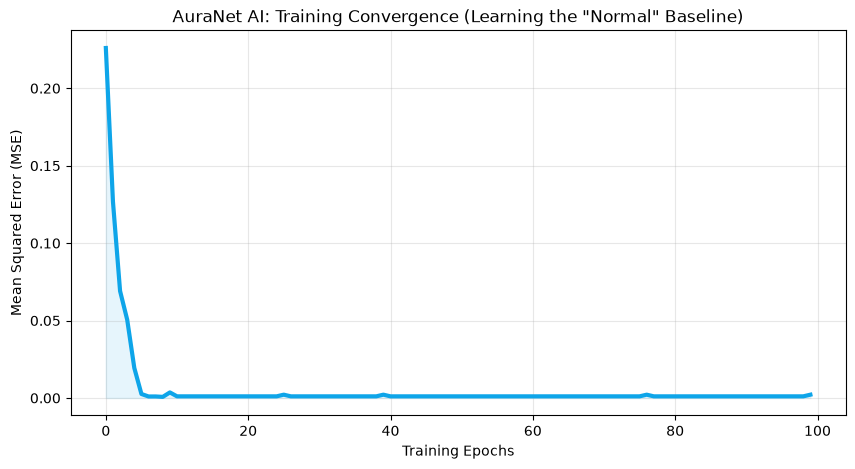

In [4]:

processor = HubbleDataProcessor(config.TRAIN_DATA_PATH)
processor.load_and_filter()
processor.engineer_features()
df_train = processor.get_dataframe()

input_dim = df_train.shape[1]
train_loader = DataLoader(HubbleDataset(df_train), batch_size=8, shuffle=True)


live_model = ZeroTrustAutoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(live_model.parameters(), lr=0.01)

epoch_history = []
loss_history = []

print(" Simulating Training to capture Loss Curve...")
for epoch in range(100):
    total_loss = 0
    for batch_features, _ in train_loader:
        reconstructed = live_model(batch_features)
        loss = criterion(reconstructed, batch_features)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    epoch_history.append(epoch)
    loss_history.append(avg_loss)


plt.figure(figsize=(10, 5))
plt.plot(epoch_history, loss_history, color='#0ea5e9', linewidth=3)
plt.title('AuraNet AI: Training Convergence (Learning the "Normal" Baseline)')
plt.xlabel('Training Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, alpha=0.3)
plt.fill_between(epoch_history, loss_history, color='#0ea5e9', alpha=0.1)
plt.show()


In [ ]:

test_processor = HubbleDataProcessor(config.TEST_DATA_PATH)
test_processor.load_and_filter()
test_processor.engineer_features()
df_test = test_processor.get_dataframe()
raw_events = test_processor.raw_data


normal_mses = []
anomaly_mses = []

# Using the model we just trained in Cell 2
live_model.eval()

for i in range(len(df_test)):
    row_tensor = torch.FloatTensor(df_test.iloc[i].values)
    context = raw_events[i]
    
    with torch.no_grad():
        reconstructed = live_model(row_tensor)
        mse_loss = criterion(reconstructed, row_tensor).item()
        
    # Heuristic for the plot: Separate known attacks from normal traffic
    if context['method'] in ['POST', 'DELETE'] or df_test.iloc[i]['is_valid_path'] == 0.0:
        anomaly_mses.append(mse_loss)
    else:
        normal_mses.append(mse_loss)

# 3. Plot Diagram 2
plt.figure(figsize=(12, 6))

# The "Tall Mountain Near Zero"
plt.hist(normal_mses, bins=15, alpha=0.8, color='#10b981', label='Benign Traffic (Mountain)')

# The "Far Plateaued Hill"
plt.hist(anomaly_mses, bins=15, alpha=0.8, color='#ef4444', label='Anomalous/Malicious Traffic (Plateau)')

# The Tripwire
plt.axvline(x=0.05, color='#f59e0b', linestyle='--', linewidth=3, label='SOC Tripwire (0.05)')

plt.title('Network Reconstruction Error: Benign vs. Threats')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Packet Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.annotate('Normal Packets\neasily reconstructed', xy=(0.01, 10), xytext=(0.05, 20),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.annotate('Zero-Day Threats\nshatter the bottleneck', xy=(0.15, 2), xytext=(0.10, 10),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.show()
